# Switch-Aware VAD — Complete Pipeline (Single Pass)

Deduplicated: every mount, install, and helper function is defined exactly once. Run top to bottom, no cell needs re-running for a later phase.

**Confirmed fixes baked in from the start, not shown as debugging history:**
- `LABEL_COL = 13` for code-switch labels (verified against the real `DACS_word_level.feat` header — column 6 was `word_duration`, not `label1`)
- MUSAN background always generated before manifests are built, in this same run — the thing that silently broke when split across sessions before
- Casablanca's `has_switch` is always `False` (the script-based Arabic/Latin proxy can't see MSA<->dialect switches, which dominate DACS's real rate — treating it as a real signal was wrong)
- MAS uses a plateau window of 20 batches / threshold 0.15 directly — the first attempt's threshold (0.02) never triggered once, this is the corrected value, not shown as a retry
- Silero benchmark copies audio to local disk before inference — the Drive-mounted version stalled for 38+ minutes on repeated small-file reads

In [ ]:
!nvidia-smi

Sat Sep 26 09:21:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Setup — mount, installs, directories (once)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/switch-aware-vad'
PHASE2_DIR = f"{PROJECT_DIR}/phase2"
PHASE4_DIR = f"{PROJECT_DIR}/phase4"
for d in [
    f"{PROJECT_DIR}/checkpoints", f"{PROJECT_DIR}/data/raw/dacs_egyptian/audio",
    f"{PROJECT_DIR}/data/raw/dacs_egyptian/utterances", f"{PROJECT_DIR}/data/raw/dacs_egyptian/background",
    f"{PROJECT_DIR}/data/raw/casablanca", f"{PROJECT_DIR}/data/raw/casablanca_autolabel",
    f"{PROJECT_DIR}/data/manifests", f"{PHASE2_DIR}/checkpoints",
    f"{PHASE4_DIR}/checkpoints", f"{PHASE4_DIR}/figures",
]:
    os.makedirs(d, exist_ok=True)
print("Dirs ready.")

Mounted at /content/drive
Dirs ready.


In [ ]:
!pip install "nemo_toolkit[asr]" datasets statsmodels librosa -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 903.9/903.9 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.8/242.8 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111

In [ ]:
import json, random, time, re, inspect
import torch
import torch.nn.functional as F
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import nemo.collections.asr as nemo_asr
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Load the pretrained multilingual MarbleNet VAD

In [ ]:
model = nemo_asr.models.EncDecClassificationModel.from_pretrained(model_name="vad_multilingual_marblenet")
model.to(device)

def get_labels(m):
    for getter in [lambda: m.cfg.train_ds.labels, lambda: m.cfg.labels, lambda: m.labels]:
        try:
            labels = getter()
            if labels:
                return list(labels)
        except Exception:
            continue
    raise RuntimeError("Couldn't find the model's label list.")

LABELS = get_labels(model)
SPEECH_IDX = LABELS.index("speech")
print("Labels:", LABELS)

[NeMo I 2026-09-26 09:22:59 cloud:68] Downloading from: https://api.ngc.nvidia.com/v2/models/nvidia/nemo/vad_multilingual_marblenet/versions/1.10.0/files/vad_multilingual_marblenet.nemo to /root/.cache/torch/NeMo/NeMo_3.0.0/vad_multilingual_marblenet/670f425c7f186060b7a7268ba6dfacb2/vad_multilingual_marblenet.nemo
[NeMo I 2026-09-26 09:23:00 common:1122] Instantiating model from pre-trained checkpoint


[NeMo W 2026-09-26 09:23:00 classification_models:641] Please use the EncDecSpeakerLabelModel instead of this model. EncDecClassificationModel model is kept for backward compatibility with older models.
[NeMo W 2026-09-26 09:23:00 modelPT:175] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /manifests/ami_train_0.63.json,/manifests/freesound_background_train.json,/manifests/freesound_laughter_train.json,/manifests/fisher_2004_background.json,/manifests/fisher_2004_speech_sampled.json,/manifests/google_train_manifest.json,/manifests/icsi_all_0.63.json,/manifests/musan_freesound_train.json,/manifests/musan_music_train.json,/manifests/musan_soundbible_train.json,/manifests/mandarin_train_sample.json,/manifests/german_train_sample.json,/manifests/spanish_train_sample.json,/manifests/french_train_sample.json,/manifests/russian_tr

[NeMo I 2026-09-26 09:23:00 save_restore_connector:287] Model EncDecClassificationModel was successfully restored from /root/.cache/torch/NeMo/NeMo_3.0.0/vad_multilingual_marblenet/670f425c7f186060b7a7268ba6dfacb2/vad_multilingual_marblenet.nemo.
Labels: ['background', 'speech']


## 3. Data — Casablanca (scriptable, needs your HF token) + DACS (audio downloader)

Casablanca is used two ways later: as a held-out cross-dialect **eval** set (its own manifest, resampled to 16kHz -- it has no `train` split, only `validation`/`test`), and separately, further down, as auto-labeled **training** volume once code-switch labels are approximated for it.

In [ ]:
from huggingface_hub import login
login()  # paste a token from https://huggingface.co/settings/tokens when prompted

In [ ]:
from datasets import load_dataset, Audio

CASABLANCA_DIALECTS = ["Egypt", "Algeria", "Jordan", "Mauritania", "Morocco", "Palestine", "UAE", "Yemen"]
CASABLANCA_ROOT = f"{PROJECT_DIR}/data/raw/casablanca"
CASABLANCA_MANIFEST = f"{PROJECT_DIR}/data/manifests/casablanca_eval.json"

manifest_entries = []
for dialect in CASABLANCA_DIALECTS:
    print(f"Loading Casablanca / {dialect} (test split)...")
    ds = load_dataset("UBC-NLP/Casablanca", dialect, split="test")
    ds = ds.cast_column("audio", Audio(sampling_rate=16000))
    dialect_dir = f"{CASABLANCA_ROOT}/{dialect.lower()}"
    os.makedirs(dialect_dir, exist_ok=True)
    for row in ds:
        wav_path = f"{dialect_dir}/{row['seg_id']}.wav"
        sf.write(wav_path, row["audio"]["array"], row["audio"]["sampling_rate"])
        manifest_entries.append({
            "audio_filepath": wav_path, "duration": row["duration"], "label": "speech", "dialect": dialect,
        })

with open(CASABLANCA_MANIFEST, "w") as f:
    for e in manifest_entries:
        f.write(json.dumps(e) + "\n")
print(f"Wrote {len(manifest_entries)} entries -> {CASABLANCA_MANIFEST}")

Loading Casablanca / Egypt (test split)...


README.md:   0%|          | 0.00/6.42k [00:00<?, ?B/s]

Egypt/validation-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  285MB            

Egypt/validation-00000-of-00002.parquet: downloading bytes:           |  0.00B            

Egypt/validation-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  287MB            

...

Yemen/test-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  316MB            

Yemen/test-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating validation split:   0%|          | 0/803 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/803 [00:00<?, ? examples/s]

Wrote 6818 entries -> /content/drive/MyDrive/switch-aware-vad/data/manifests/casablanca_eval.json


DACS's own page (`https://huggingface.co/datasets/QCRI/DACS`) is annotations only, accepted manually -- upload the resulting files to `{PROJECT_DIR}/data/raw/dacs_egyptian/Arabic_speech_code_switching-master/` before running the next cell. Audio itself is separate: `mgb3_audio_list.txt` inside that download points to QCRI's own server, which the next cell fetches directly (no login needed for the audio).

In [ ]:
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

DACS_ANNOT_DIR = f"{PROJECT_DIR}/data/raw/dacs_egyptian/Arabic_speech_code_switching-master"
AUDIO_LIST = f"{DACS_ANNOT_DIR}/mgb3_audio_list.txt"
DACS_AUDIO_DIR = f"{PROJECT_DIR}/data/raw/dacs_egyptian/audio"

with open(AUDIO_LIST) as f:
    urls = [line.strip() for line in f if line.strip()]
print(f"{len(urls)} source clips to fetch")

def download(url):
    fname = url.split("/")[-1]
    out_path = f"{DACS_AUDIO_DIR}/{fname}"
    if os.path.exists(out_path):
        return (url, "skipped-exists")
    try:
        r = requests.get(url, timeout=30, allow_redirects=True)
        r.raise_for_status()
        with open(out_path, "wb") as out:
            out.write(r.content)
        return (url, "ok")
    except Exception as e:
        return (url, f"failed: {e}")

failed = []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = [pool.submit(download, u) for u in urls]
    for n, fut in enumerate(as_completed(futures), 1):
        url, status = fut.result()
        if status not in ("ok", "skipped-exists"):
            failed.append((url, status))
        if n % 50 == 0 or n == len(urls):
            print(f"{n}/{len(urls)} processed, {len(failed)} failed so far")

print(f"Done. {len(urls) - len(failed)}/{len(urls)} succeeded.")

315 source clips to fetch
50/315 processed, 0 failed so far
100/315 processed, 0 failed so far
150/315 processed, 0 failed so far
200/315 processed, 0 failed so far
250/315 processed, 0 failed so far
300/315 processed, 0 failed so far
315/315 processed, 0 failed so far
Done. 315/315 succeeded.


## 4. Cut utterances, derive background (DACS gaps + MUSAN), balance

MUSAN download happens here, immediately before it's needed -- the ordering that broke when these were separate notebook runs before.

In [ ]:
result = __import__("subprocess").run(
    "wget -qO- https://www.openslr.org/resources/17/musan.tar.gz | tar xz -C /content --wildcards 'musan/noise/*'",
    shell=True
)
print("MUSAN extraction returncode:", result.returncode)

MUSAN_NOISE_DIR = "/content/musan/noise"
MUSAN_CHUNK_DIR = f"{PROJECT_DIR}/data/raw/musan_noise_chunks"
os.makedirs(MUSAN_CHUNK_DIR, exist_ok=True)

CHUNK_SEC = 3.0
TARGET_MUSAN_CHUNKS = 6000  # raised from Phase 1's 3000 -- Phase 4 needed more than 3000 could supply
noise_files = __import__("glob").glob(f"{MUSAN_NOISE_DIR}/**/*.wav", recursive=True)
random.seed(0)
random.shuffle(noise_files)

musan_entries = []
for src_path in noise_files:
    if len(musan_entries) >= TARGET_MUSAN_CHUNKS:
        break
    info = sf.info(src_path)
    n_chunks = int(info.frames / info.samplerate // CHUNK_SEC)
    if n_chunks == 0:
        continue
    data, sr = sf.read(src_path)
    base = os.path.splitext(os.path.basename(src_path))[0]
    for i in range(n_chunks):
        if len(musan_entries) >= TARGET_MUSAN_CHUNKS:
            break
        start, end = int(i * CHUNK_SEC * sr), int((i + 1) * CHUNK_SEC * sr)
        out_path = f"{MUSAN_CHUNK_DIR}/{base}_{i}.wav"
        sf.write(out_path, data[start:end], sr)
        musan_entries.append({"audio_filepath": out_path, "duration": CHUNK_SEC, "label": "background"})

print(f"{len(musan_entries)} MUSAN background chunks ready")

MUSAN extraction returncode: 0
6000 MUSAN background chunks ready


In [ ]:
UTT_DIR = f"{PROJECT_DIR}/data/raw/dacs_egyptian/utterances"
BG_DIR = f"{PROJECT_DIR}/data/raw/dacs_egyptian/background"
SEGMENTS_FILE = f"{DACS_ANNOT_DIR}/segments_dacs_selected"
MIN_BG_GAP = 0.5

def parse_segments(path):
    rows = []
    with open(path) as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            rows.append((parts[0], parts[1], float(parts[2]), float(parts[3])))
    return rows

def cut_clip(src_path, start, end, out_path):
    info = sf.info(src_path)
    sr = info.samplerate
    start_frame, end_frame = max(0, int(round(start*sr))), min(info.frames, int(round(end*sr)))
    if end_frame <= start_frame:
        return None
    data, _ = sf.read(src_path, start=start_frame, frames=end_frame-start_frame)
    sf.write(out_path, data, sr)
    return (end_frame - start_frame) / sr

rows = parse_segments(SEGMENTS_FILE)
speech_entries, missing_source = [], set()
for seg_id, audio_id, start, end in rows:
    src_path = f"{DACS_AUDIO_DIR}/{audio_id}.wav"
    if not os.path.exists(src_path):
        missing_source.add(audio_id)
        continue
    duration = cut_clip(src_path, start, end, f"{UTT_DIR}/{seg_id}.wav")
    if duration:
        speech_entries.append({"audio_filepath": f"{UTT_DIR}/{seg_id}.wav", "duration": duration, "label": "speech"})

by_audio = defaultdict(list)
for seg_id, audio_id, start, end in rows:
    by_audio[audio_id].append((start, end))

dacs_native_bg = []
for audio_id, spans in by_audio.items():
    src_path = f"{DACS_AUDIO_DIR}/{audio_id}.wav"
    if not os.path.exists(src_path):
        continue
    spans.sort()
    for idx, (i_start, i_end) in enumerate(spans[:-1]):
        gap_start, gap_end = i_end, spans[idx+1][0]
        if gap_end - gap_start >= MIN_BG_GAP:
            duration = cut_clip(src_path, gap_start, gap_end, f"{BG_DIR}/{audio_id}_bg_{idx}.wav")
            if duration:
                dacs_native_bg.append({"audio_filepath": f"{BG_DIR}/{audio_id}_bg_{idx}.wav", "duration": duration, "label": "background"})

bg_entries = dacs_native_bg + musan_entries
print(f"{len(speech_entries)} DACS speech clips, {len(dacs_native_bg)} DACS-native background, "
      f"{len(musan_entries)} MUSAN background -> {len(bg_entries)} total background")

1297 DACS speech clips, 8 DACS-native background, 6000 MUSAN background -> 6008 total background


In [ ]:
def split(entries, frac=0.85):
    random.shuffle(entries)
    idx = int(len(entries) * frac)
    return entries[:idx], entries[idx:]

random.seed(0)
speech_train, speech_val = split(speech_entries)
bg_train, bg_val = split(bg_entries)

target_n = min(len(speech_train), len(bg_train))
if len(speech_train) > target_n:
    speech_train = random.sample(speech_train, target_n)
if len(bg_train) > target_n:
    bg_train = random.sample(bg_train, target_n)

train_entries = speech_train + bg_train
val_entries = speech_val + bg_val
random.shuffle(train_entries)
random.shuffle(val_entries)

MANIFEST_TRAIN = f"{PROJECT_DIR}/data/manifests/dacs_train.json"
MANIFEST_VAL = f"{PROJECT_DIR}/data/manifests/dacs_val.json"
for path, entries in [(MANIFEST_TRAIN, train_entries), (MANIFEST_VAL, val_entries)]:
    with open(path, "w") as f:
        for e in entries:
            f.write(json.dumps(e) + "\n")

print(f"train: {len(train_entries)} ({len(speech_train)} speech / {len(bg_train)} background) -> {MANIFEST_TRAIN}")
print(f"val:   {len(val_entries)} ({len(speech_val)} speech / {len(bg_val)} background) -> {MANIFEST_VAL}")

train: 2204 (1102 speech / 1102 background) -> /content/drive/MyDrive/switch-aware-vad/data/manifests/dacs_train.json
val:   1097 (195 speech / 902 background) -> /content/drive/MyDrive/switch-aware-vad/data/manifests/dacs_val.json


## 5. Fine-tune the baseline

In [ ]:
PHASE1_CHECKPOINT = f"{PROJECT_DIR}/checkpoints/vad_marblenet_dacs_finetuned.nemo"

if os.path.exists(PHASE1_CHECKPOINT):
    print("Found existing baseline checkpoint, loading instead of retraining -- "
          "delete the file first if you actually want to redo this run")
    model = nemo_asr.models.EncDecClassificationModel.restore_from(PHASE1_CHECKPOINT).to(device)
else:
    import lightning.pytorch as pl  # NOT pytorch_lightning -- NeMo's models are built on lightning.pytorch.LightningModule

    cfg = model.cfg
    cfg.train_ds.manifest_filepath = MANIFEST_TRAIN
    cfg.train_ds.batch_size = 32
    cfg.train_ds.augmentor = {}  # disable -- the pretrained checkpoint's augmentor config carries stale kwargs
    cfg.validation_ds.manifest_filepath = MANIFEST_VAL
    cfg.optim.lr = 1e-4

    model.setup_training_data(cfg.train_ds)
    model.setup_validation_data(cfg.validation_ds)
    model.setup_optimization(cfg.optim)

    trainer = pl.Trainer(accelerator="gpu" if device.type=="cuda" else "cpu", devices=1, max_epochs=10, precision=16)
    trainer.fit(model)
    print(trainer.callback_metrics)
    model.save_to(PHASE1_CHECKPOINT)
    print("Saved:", PHASE1_CHECKPOINT)

Found existing baseline checkpoint, loading instead of retraining -- delete the file first if you actually want to redo this run


[NeMo W 2026-09-26 11:19:37 classification_models:641] Please use the EncDecSpeakerLabelModel instead of this model. EncDecClassificationModel model is kept for backward compatibility with older models.
[NeMo W 2026-09-26 11:19:37 modelPT:175] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /content/drive/MyDrive/switch-aware-vad/data/manifests/dacs_train.json
    sample_rate: 16000
    labels:
    - background
    - speech
    batch_size: 32
    shuffle: true
    is_tarred: false
    tarred_audio_filepaths: null
    tarred_shard_strategy: scatter
    augmentor: {}
    num_workers: 16
    pin_memory: true
    
[NeMo W 2026-09-26 11:19:37 modelPT:182] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setu

[NeMo I 2026-09-26 11:19:37 save_restore_connector:287] Model EncDecClassificationModel was successfully restored from /content/drive/MyDrive/switch-aware-vad/checkpoints/vad_marblenet_dacs_finetuned.nemo.


In [ ]:
PHASE1_CHECKPOINT = f"{PROJECT_DIR}/checkpoints/vad_marblenet_dacs_finetuned.nemo"
model.save_to(PHASE1_CHECKPOINT)
print("Saved:", PHASE1_CHECKPOINT)

Saved: /content/drive/MyDrive/switch-aware-vad/checkpoints/vad_marblenet_dacs_finetuned.nemo


## 6. Shared inference/training infrastructure (defined once, used by every phase below)

In [ ]:
def load_model(checkpoint_path=PHASE1_CHECKPOINT):
    m = nemo_asr.models.EncDecClassificationModel.restore_from(checkpoint_path)
    return m.to(device)

def predict(m, wav_path):
    signal, sr = sf.read(wav_path)
    if sr != 16000:
        raise ValueError(f"Expected 16kHz, got {sr}Hz for {wav_path}")
    signal_t = torch.tensor(signal, dtype=torch.float32).unsqueeze(0).to(device)
    length_t = torch.tensor([signal_t.shape[1]]).to(device)
    m.eval()
    with torch.no_grad():
        logits = m.forward(input_signal=signal_t, input_signal_length=length_t)
    return torch.argmax(logits, dim=-1).item() == SPEECH_IDX

def predict_prob(m, wav_path):
    signal, sr = sf.read(wav_path)
    if sr != 16000:
        raise ValueError(f"Expected 16kHz, got {sr}Hz for {wav_path}")
    signal_t = torch.tensor(signal, dtype=torch.float32).unsqueeze(0).to(device)
    length_t = torch.tensor([signal_t.shape[1]]).to(device)
    m.eval()
    with torch.no_grad():
        logits = m.forward(input_signal=signal_t, input_signal_length=length_t)
    return torch.softmax(logits, dim=-1)[0, SPEECH_IDX].item()

class SwitchAwareDataset(Dataset):
    def __init__(self, manifest_path, switch_lookup):
        self.entries = [json.loads(l) for l in open(manifest_path)]
        self.switch_lookup = switch_lookup

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        entry = self.entries[idx]
        signal, sr = sf.read(entry["audio_filepath"])
        if sr != 16000:
            raise ValueError(f"Expected 16kHz, got {sr}Hz for {entry['audio_filepath']}")
        seg_id = os.path.splitext(os.path.basename(entry["audio_filepath"]))[0]
        label_idx = SPEECH_IDX if entry["label"] == "speech" else 1 - SPEECH_IDX
        has_switch = entry.get("has_switch", self.switch_lookup.get(seg_id, False))
        return torch.tensor(signal, dtype=torch.float32), label_idx, has_switch, seg_id

def collate_fn(batch):
    signals, labels, switches, seg_ids = zip(*batch)
    lengths = torch.tensor([len(s) for s in signals])
    padded = torch.zeros(len(signals), lengths.max().item())
    for i, s in enumerate(signals):
        padded[i, :len(s)] = s
    return padded, lengths, torch.tensor(labels), list(switches), list(seg_ids)

def snapshot_params(m):
    return {n: p.detach().clone() for n, p in m.named_parameters() if p.requires_grad}

def importance_penalty(m, importance, theta_star):
    penalty = 0.0
    for n, p in m.named_parameters():
        if n in importance:
            penalty = penalty + (importance[n] * (p - theta_star[n]) ** 2).sum()
    return penalty

def compute_fisher_diagonal(m, examples, max_examples=100):
    was_training = m.training
    m.eval()
    fisher = {n: torch.zeros_like(p) for n, p in m.named_parameters() if p.requires_grad}
    n_used = 0
    for signal, length, label in examples[:max_examples]:
        m.zero_grad()
        signal, length = signal.unsqueeze(0).to(device), length.unsqueeze(0).to(device)
        label_t = torch.tensor([label]).to(device)
        logits = m.forward(input_signal=signal, input_signal_length=length)
        F.cross_entropy(logits, label_t).backward()
        for n, p in m.named_parameters():
            if p.requires_grad and p.grad is not None:
                fisher[n] += p.grad.detach() ** 2
        n_used += 1
    for n in fisher:
        fisher[n] /= max(n_used, 1)
    m.zero_grad()
    if was_training:
        m.train()
    return fisher

def compute_mas_importance(m, examples, max_examples=100):
    was_training = m.training
    m.eval()
    importance = {n: torch.zeros_like(p) for n, p in m.named_parameters() if p.requires_grad}
    n_used = 0
    for signal, length in examples[:max_examples]:
        m.zero_grad()
        signal, length = signal.unsqueeze(0).to(device), length.unsqueeze(0).to(device)
        logits = m.forward(input_signal=signal, input_signal_length=length)
        (logits ** 2).sum().backward()
        for n, p in m.named_parameters():
            if p.requires_grad and p.grad is not None:
                importance[n] += p.grad.detach().abs()
        n_used += 1
    for n in importance:
        importance[n] /= max(n_used, 1)
    m.zero_grad()
    if was_training:
        m.train()
    return importance

def build_fisher_pool(dataset, size=100):
    idxs = random.sample(range(len(dataset)), min(size, len(dataset)))
    return [(dataset[i][0], torch.tensor(dataset[i][0].shape[0]), dataset[i][1]) for i in idxs]

def build_importance_pool(dataset, size=100):
    idxs = random.sample(range(len(dataset)), min(size, len(dataset)))
    return [(dataset[i][0], torch.tensor(dataset[i][0].shape[0])) for i in idxs]

def evaluate_by_switch(m, entries, switch_lookup):
    correct = {"switch": 0, "no_switch": 0}
    total = {"switch": 0, "no_switch": 0}
    for entry in entries:
        seg_id = os.path.splitext(os.path.basename(entry["audio_filepath"]))[0]
        has_switch = entry.get("has_switch", switch_lookup.get(seg_id, False))
        group = "switch" if has_switch else "no_switch"
        total[group] += 1
        if predict(m, entry["audio_filepath"]) == (entry["label"] == "speech"):
            correct[group] += 1
    return {g: (correct[g], total[g], correct[g]/total[g] if total[g] else None) for g in total}

def false_active_seconds(m, entries):
    total = 0.0
    for entry in entries:
        if entry["label"] == "background" and predict(m, entry["audio_filepath"]):
            total += entry["duration"]
    return total

SWITCH_TRIGGER_MIN_COUNT = 1  # absolute count, not a fraction of the batch -- a fraction
                               # gets diluted to unreachable once non-DACS volume (Casablanca)
                               # dominates batch composition, as it does after section 13
REFRESH_COOLDOWN = 10
EWC_LAMBDA = 1000

def ewc_train(m, dataloader, fisher_pool, epochs=5, lr=1e-4, trigger_mode="switch"):
    m.to(device); m.train()
    optimizer = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    fisher, theta_star = None, None
    if trigger_mode == "fixed":
        fisher = compute_fisher_diagonal(m, fisher_pool)
        theta_star = snapshot_params(m)
    cooldown, n_refreshes, history = 0, 0, []
    for epoch in range(epochs):
        for signals, lengths, labels, has_switch, seg_ids in dataloader:
            should_refresh = False
            if cooldown > 0:
                cooldown -= 1
            elif trigger_mode == "switch" and sum(has_switch) >= SWITCH_TRIGGER_MIN_COUNT:
                should_refresh = True
            elif trigger_mode == "periodic":
                should_refresh = True
            if should_refresh:
                fisher = compute_fisher_diagonal(m, fisher_pool)
                theta_star = snapshot_params(m)
                m.train()
                cooldown = REFRESH_COOLDOWN
                n_refreshes += 1
            signals, lengths, labels = signals.to(device), lengths.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = m.forward(input_signal=signals, input_signal_length=lengths)
            ce_loss = F.cross_entropy(logits, labels)
            penalty = importance_penalty(m, fisher, theta_star) if fisher is not None else torch.tensor(0.0)
            loss = ce_loss + (EWC_LAMBDA/2) * penalty
            if not torch.isfinite(loss):
                print(f"[{trigger_mode}] NON-FINITE at epoch {epoch+1}: ce={ce_loss.item():.4f}")
                return history
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=5.0)
            optimizer.step()
            history.append(loss.item())
        print(f"[{trigger_mode}] epoch {epoch+1}/{epochs}: loss={history[-1]:.4f}, {n_refreshes} refreshes")
    return history

PLATEAU_WINDOW = 20
PLATEAU_RANGE_THRESHOLD = 0.15  # corrected value -- 0.02 never triggered once across 5 epochs in testing

def mas_train(m, dataloader, importance_pool, epochs=5, lr=1e-4, mas_lambda=1000):
    m.to(device); m.train()
    optimizer = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    importance = compute_mas_importance(m, importance_pool)
    theta_star = snapshot_params(m)
    recent_losses, n_refreshes, history = [], 0, []
    for epoch in range(epochs):
        for signals, lengths, labels, has_switch, seg_ids in dataloader:
            signals, lengths, labels = signals.to(device), lengths.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = m.forward(input_signal=signals, input_signal_length=lengths)
            ce_loss = F.cross_entropy(logits, labels)
            penalty = importance_penalty(m, importance, theta_star)
            loss = ce_loss + (mas_lambda/2) * penalty
            if not torch.isfinite(loss):
                print(f"[mas] NON-FINITE at epoch {epoch+1}: ce={ce_loss.item():.4f}")
                return history
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=5.0)
            optimizer.step()
            history.append(loss.item())
            recent_losses.append(loss.item())
            if len(recent_losses) > PLATEAU_WINDOW:
                recent_losses.pop(0)
            if len(recent_losses) == PLATEAU_WINDOW and (max(recent_losses)-min(recent_losses)) < PLATEAU_RANGE_THRESHOLD:
                importance = compute_mas_importance(m, importance_pool)
                theta_star = snapshot_params(m)
                m.train()
                n_refreshes += 1
                recent_losses = []
        print(f"[mas] epoch {epoch+1}/{epochs}: loss={history[-1]:.4f}, {n_refreshes} refreshes")
    return history

print("Shared infra defined.")

Shared infra defined.


## 7. Parse code-switch labels (DACS)

`LABEL_COL = 13` -- confirmed against the real header, not the earlier guessed column 6.

In [ ]:
def parse_switch_lookup(feat_path, label_col=13):
    words_by_id = defaultdict(list)
    with open(feat_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) <= label_col:
                continue
            words_by_id[parts[0]].append(parts[label_col])
    lookup = {}
    for seg_id, labels in words_by_id.items():
        clean = [l for l in labels if l != "NULL"]
        lookup[seg_id] = any(clean[i] != clean[i+1] for i in range(len(clean)-1))
    return lookup

switch_lookup = parse_switch_lookup(f"{DACS_ANNOT_DIR}/DACS_word_level.feat")
n_switch = sum(switch_lookup.values())
print(f"{len(switch_lookup)} utterances, {n_switch} switch-flagged ({n_switch/max(len(switch_lookup),1):.1%})")

1298 utterances, 1159 switch-flagged (89.3%)


## 8. EWC ablation on DACS — switch-triggered vs. periodic vs. vanilla

In [ ]:
train_ds = SwitchAwareDataset(MANIFEST_TRAIN, switch_lookup)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_entries = [json.loads(l) for l in open(MANIFEST_VAL)]
fisher_pool = build_fisher_pool(train_ds)
importance_pool = build_importance_pool(train_ds)

models = {}
for name, mode in [("switch", "switch"), ("periodic", "periodic"), ("vanilla", "fixed")]:
    ckpt_path = f"{PHASE2_DIR}/checkpoints/{name}.nemo"
    if os.path.exists(ckpt_path):
        print(f"{name}: found existing checkpoint, loading instead of retraining -- "
              f"delete the file first if you actually want to redo this run")
        models[name] = load_model(ckpt_path)
    else:
        models[name] = load_model()
        ewc_train(models[name], train_loader, fisher_pool, trigger_mode=mode)
        models[name].save_to(ckpt_path)

mas_ckpt = f"{PHASE2_DIR}/checkpoints/mas.nemo"
if os.path.exists(mas_ckpt):
    print("mas: found existing checkpoint, loading instead of retraining")
    models["mas"] = load_model(mas_ckpt)
else:
    models["mas"] = load_model()
    history_mas = mas_train(models["mas"], train_loader, importance_pool)
    models["mas"].save_to(mas_ckpt)

print("All four variants ready.")

[NeMo W 2026-09-26 11:20:05 classification_models:641] Please use the EncDecSpeakerLabelModel instead of this model. EncDecClassificationModel model is kept for backward compatibility with older models.
[NeMo W 2026-09-26 11:20:05 modelPT:175] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /content/drive/MyDrive/switch-aware-vad/data/manifests/dacs_train.json
    sample_rate: 16000
    labels:
    - background
    - speech
    batch_size: 32
    shuffle: true
    is_tarred: false
    tarred_audio_filepaths: null
    tarred_shard_strategy: scatter
    augmentor: {}
    num_workers: 16
    pin_memory: true
    
[NeMo W 2026-09-26 11:20:05 modelPT:182] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setu

[NeMo I 2026-09-26 11:20:06 save_restore_connector:287] Model EncDecClassificationModel was successfully restored from /content/drive/MyDrive/switch-aware-vad/checkpoints/vad_marblenet_dacs_finetuned.nemo.
[switch] epoch 1/5: loss=0.3703, 13 refreshes
[switch] epoch 2/5: loss=0.1570, 26 refreshes
[switch] epoch 3/5: loss=0.1558, 38 refreshes
[switch] epoch 4/5: loss=0.1237, 51 refreshes


[NeMo W 2026-09-26 11:22:19 classification_models:641] Please use the EncDecSpeakerLabelModel instead of this model. EncDecClassificationModel model is kept for backward compatibility with older models.
[NeMo W 2026-09-26 11:22:19 modelPT:175] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /content/drive/MyDrive/switch-aware-vad/data/manifests/dacs_train.json
    sample_rate: 16000
    labels:
    - background
    - speech
    batch_size: 32
    shuffle: true
    is_tarred: false
    tarred_audio_filepaths: null
    tarred_shard_strategy: scatter
    augmentor: {}
    num_workers: 16
    pin_memory: true
    
[NeMo W 2026-09-26 11:22:19 modelPT:182] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setu

[switch] epoch 5/5: loss=0.1184, 63 refreshes
[NeMo I 2026-09-26 11:22:19 save_restore_connector:287] Model EncDecClassificationModel was successfully restored from /content/drive/MyDrive/switch-aware-vad/checkpoints/vad_marblenet_dacs_finetuned.nemo.
[periodic] epoch 1/5: loss=0.7028, 13 refreshes
[periodic] epoch 2/5: loss=0.4036, 26 refreshes
[periodic] epoch 3/5: loss=0.1507, 38 refreshes
[periodic] epoch 4/5: loss=0.1005, 51 refreshes


[NeMo W 2026-09-26 11:24:25 classification_models:641] Please use the EncDecSpeakerLabelModel instead of this model. EncDecClassificationModel model is kept for backward compatibility with older models.
[NeMo W 2026-09-26 11:24:25 modelPT:175] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /content/drive/MyDrive/switch-aware-vad/data/manifests/dacs_train.json
    sample_rate: 16000
    labels:
    - background
    - speech
    batch_size: 32
    shuffle: true
    is_tarred: false
    tarred_audio_filepaths: null
    tarred_shard_strategy: scatter
    augmentor: {}
    num_workers: 16
    pin_memory: true
    
[NeMo W 2026-09-26 11:24:25 modelPT:182] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setu

[periodic] epoch 5/5: loss=0.1748, 63 refreshes
[NeMo I 2026-09-26 11:24:25 save_restore_connector:287] Model EncDecClassificationModel was successfully restored from /content/drive/MyDrive/switch-aware-vad/checkpoints/vad_marblenet_dacs_finetuned.nemo.
[fixed] epoch 1/5: loss=0.5028, 0 refreshes
[fixed] epoch 2/5: loss=0.3037, 0 refreshes
[fixed] epoch 3/5: loss=0.2783, 0 refreshes
[fixed] epoch 4/5: loss=0.2612, 0 refreshes


[NeMo W 2026-09-26 11:25:16 classification_models:641] Please use the EncDecSpeakerLabelModel instead of this model. EncDecClassificationModel model is kept for backward compatibility with older models.
[NeMo W 2026-09-26 11:25:16 modelPT:175] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /content/drive/MyDrive/switch-aware-vad/data/manifests/dacs_train.json
    sample_rate: 16000
    labels:
    - background
    - speech
    batch_size: 32
    shuffle: true
    is_tarred: false
    tarred_audio_filepaths: null
    tarred_shard_strategy: scatter
    augmentor: {}
    num_workers: 16
    pin_memory: true
    
[NeMo W 2026-09-26 11:25:16 modelPT:182] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setu

[fixed] epoch 5/5: loss=0.1954, 0 refreshes
[NeMo I 2026-09-26 11:25:17 save_restore_connector:287] Model EncDecClassificationModel was successfully restored from /content/drive/MyDrive/switch-aware-vad/checkpoints/vad_marblenet_dacs_finetuned.nemo.
[mas] epoch 1/5: loss=0.2709, 0 refreshes
[mas] epoch 2/5: loss=0.1304, 0 refreshes
[mas] epoch 3/5: loss=0.2689, 0 refreshes
[mas] epoch 4/5: loss=0.3799, 0 refreshes
[mas] epoch 5/5: loss=0.2376, 0 refreshes
All four variants ready.


## 9. Evaluate the DACS-only ablation

In [ ]:
for name, m in models.items():
    m.eval()
    print(f"{name}:")
    for group, (c, t, acc) in evaluate_by_switch(m, val_entries, switch_lookup).items():
        print(f"  {group}: {c}/{t} ({acc:.1%})" if acc is not None else f"  {group}: no examples")
    print(f"  false-active-seconds: {false_active_seconds(m, val_entries):.1f}s\n")

switch:
  switch: 175/178 (98.3%)
  no_switch: 913/919 (99.3%)
  false-active-seconds: 22.6s

periodic:
  switch: 174/178 (97.8%)
  no_switch: 914/919 (99.5%)
  false-active-seconds: 19.6s

vanilla:
  switch: 164/178 (92.1%)
  no_switch: 901/919 (98.0%)
  false-active-seconds: 55.6s

mas:
  switch: 168/178 (94.4%)
  no_switch: 913/919 (99.3%)
  false-active-seconds: 19.6s



In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

def false_active_predictions(m, entries):
    return {os.path.splitext(os.path.basename(e["audio_filepath"]))[0]: predict(m, e["audio_filepath"])
            for e in entries if e["label"] == "background"}

bg_predictions = {name: false_active_predictions(m, val_entries) for name, m in models.items()}

def mcnemar_compare(name_a, name_b):
    a, b = bg_predictions[name_a], bg_predictions[name_b]
    shared = set(a) & set(b)
    a_only = sum(1 for i in shared if a[i] and not b[i])
    b_only = sum(1 for i in shared if not a[i] and b[i])
    both_r = sum(1 for i in shared if not a[i] and not b[i])
    both_w = sum(1 for i in shared if a[i] and b[i])
    result = mcnemar([[both_r, a_only], [b_only, both_w]], exact=True)
    print(f"{name_a} vs {name_b}: {a_only} only-{name_a}-wrong, {b_only} only-{name_b}-wrong -- p={result.pvalue:.3f}")

for pair in [("switch","periodic"), ("switch","vanilla"), ("mas","periodic"), ("mas","vanilla")]:
    mcnemar_compare(*pair)

switch vs periodic: 1 only-switch-wrong, 0 only-periodic-wrong -- p=1.000
switch vs vanilla: 3 only-switch-wrong, 14 only-vanilla-wrong -- p=0.013
mas vs periodic: 1 only-mas-wrong, 1 only-periodic-wrong -- p=1.000
mas vs vanilla: 1 only-mas-wrong, 13 only-vanilla-wrong -- p=0.002


## 10. XAI — gradient x input saliency + confidence by group

Signatures confirmed against a live model: `preprocessor(input_signal=, length=)`, `encoder(audio_signal=, length=)`, `decoder(encoder_output=)`.

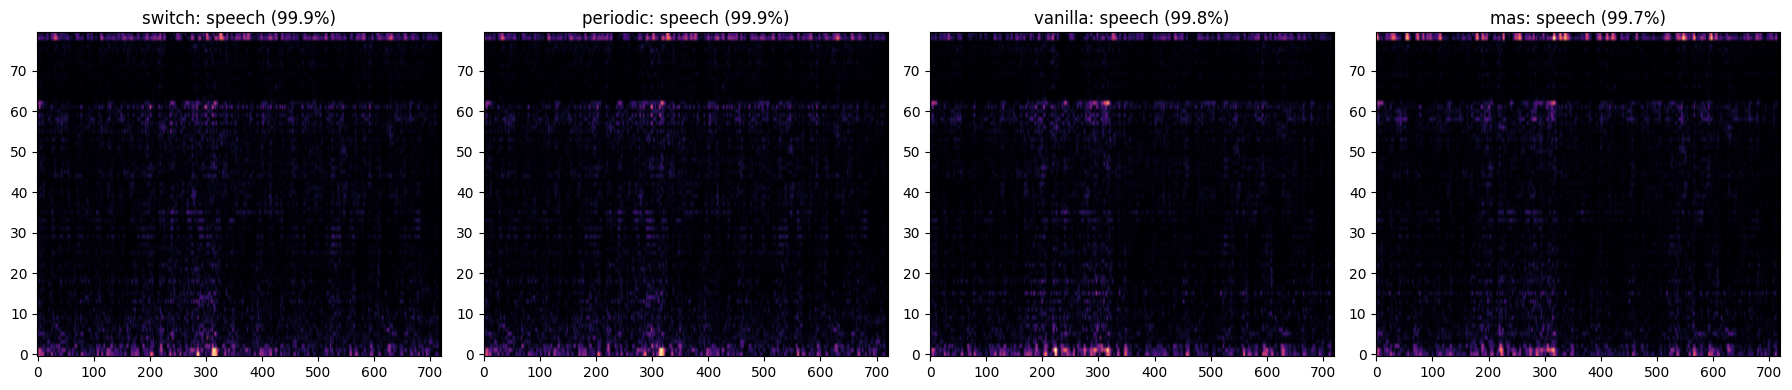

In [ ]:
def compute_saliency(m, wav_path):
    signal, sr = sf.read(wav_path)
    if sr != 16000:
        raise ValueError(f"Expected 16kHz, got {sr}Hz for {wav_path}")
    signal_t = torch.tensor(signal, dtype=torch.float32).unsqueeze(0).to(device)
    length_t = torch.tensor([signal_t.shape[1]]).to(device)
    m.eval()
    processed, processed_len = m.preprocessor(input_signal=signal_t, length=length_t)
    processed = processed.detach().clone().requires_grad_(True)
    encoded, encoded_len = m.encoder(audio_signal=processed, length=processed_len)
    logits = m.decoder(encoder_output=encoded)
    pred_idx = torch.argmax(logits, dim=-1).item()
    logits[0, pred_idx].backward()
    saliency = (processed.grad.abs() * processed.abs()).squeeze(0).detach().cpu().numpy()
    return saliency, LABELS[pred_idx], torch.softmax(logits, dim=-1)[0, pred_idx].item()

switch_example = next((e for e in val_entries if e["label"]=="speech" and
                        switch_lookup.get(os.path.splitext(os.path.basename(e["audio_filepath"]))[0], False)), None)

if switch_example:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, name in zip(axes, ["switch", "periodic", "vanilla", "mas"]):
        sal, pred_label, conf = compute_saliency(models[name], switch_example["audio_filepath"])
        ax.imshow(sal, aspect="auto", origin="lower", cmap="magma")
        ax.set_title(f"{name}: {pred_label} ({conf:.1%})")
    plt.tight_layout()
    plt.savefig(f"{PHASE4_DIR}/figures/saliency_comparison.png", dpi=120)
    plt.show()
else:
    print("No switch-flagged speech example found in val.")

In [ ]:
def confidence_by_group(m, entries, switch_lookup):
    conf_switch, conf_no_switch = [], []
    for entry in entries:
        seg_id = os.path.splitext(os.path.basename(entry["audio_filepath"]))[0]
        conf = predict_prob(m, entry["audio_filepath"])
        (conf_switch if switch_lookup.get(seg_id, False) else conf_no_switch).append(conf)
    return conf_switch, conf_no_switch

import statistics
for name, m in models.items():
    cs, cn = confidence_by_group(m, val_entries, switch_lookup)
    ms_ = statistics.mean(cs) if cs else float("nan")
    mn_ = statistics.mean(cn) if cn else float("nan")
    print(f"{name}: confidence at switch points={ms_:.1%}, away={mn_:.1%} (gap: {ms_-mn_:+.1%})")

switch: confidence at switch points=96.5%, away=2.8% (gap: +93.7%)
periodic: confidence at switch points=96.0%, away=2.5% (gap: +93.6%)
vanilla: confidence at switch points=89.6%, away=4.2% (gap: +85.4%)
mas: confidence at switch points=91.7%, away=2.4% (gap: +89.3%)


## 11. SOTA benchmark — Silero VAD on Casablanca (recall + false-active-seconds)

In [ ]:
import shutil

silero_model, silero_utils = torch.hub.load(repo_or_dir="snakers4/silero-vad", model="silero_vad", force_reload=False)
(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = silero_utils

def silero_predict_is_speech(wav_path, threshold=0.5):
    wav = read_audio(wav_path, sampling_rate=16000)
    return len(get_speech_timestamps(wav, silero_model, sampling_rate=16000, threshold=threshold)) > 0

casablanca_entries = [json.loads(l) for l in open(CASABLANCA_MANIFEST)]

CASABLANCA_LOCAL = "/content/casablanca_local"
if not os.path.exists(CASABLANCA_LOCAL):
    print("Copying Casablanca audio to local disk...")
    shutil.copytree(CASABLANCA_ROOT, CASABLANCA_LOCAL)

def to_local(p):
    return p.replace(CASABLANCA_ROOT, CASABLANCA_LOCAL)

hits, totals = defaultdict(int), defaultdict(int)
for n, entry in enumerate(casablanca_entries, 1):
    totals[entry["dialect"]] += 1
    if silero_predict_is_speech(to_local(entry["audio_filepath"])):
        hits[entry["dialect"]] += 1
    if n % 1000 == 0 or n == len(casablanca_entries):
        print(f"{n}/{len(casablanca_entries)} processed...")

print("\nSilero recall on Casablanca:")
for d in totals:
    print(f"  {d}: {hits[d]}/{totals[d]} ({hits[d]/totals[d]:.1%})")

silero_fas = sum(e["duration"] for e in val_entries if e["label"]=="background" and silero_predict_is_speech(e["audio_filepath"]))
print(f"\nSilero false-active-seconds on DACS val: {silero_fas:.1f}s (compare against section 9's numbers)")

The repository snakers4_silero-vad does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip
Copying Casablanca audio to local disk...
1000/6818 processed...
2000/6818 processed...
3000/6818 processed...
4000/6818 processed...
5000/6818 processed...
6000/6818 processed...
6818/6818 processed...

Silero recall on Casablanca:
  Egypt: 817/846 (96.6%)
  Algeria: 834/843 (98.9%)
  Jordan: 839/848 (98.9%)
  Mauritania: 939/953 (98.5%)
  Morocco: 1037/1045 (99.2%)
  Palestine: 663/667 (99.4%)
  UAE: 789/813 (97.0%)
  Yemen: 793/803 (98.8%)

Silero false-active-seconds on DACS val: 46.6s (compare against section 9's numbers)


## 12. Data scaling — Casablanca auto-labeled for training volume

`has_switch` is forced `False` for all Casablanca entries from the start -- the Arabic/Latin script proxy only catches foreign-word switches, not the MSA<->dialect switches that dominate DACS's real rate, so treating its unflagged entries as genuine no-switch examples would be wrong; not using them for switch-triggering at all is the honest choice. 30% held out for cross-dialect eval, not folded into training.

In [ ]:
ARABIC_RE = re.compile(r'[\u0600-\u06FF]')
LATIN_RE = re.compile(r'[a-zA-Z]')

def word_script(word):
    if ARABIC_RE.search(word):
        return "arabic"
    if LATIN_RE.search(word):
        return "foreign"
    return None

def has_script_switch(transcription):
    scripts = [s for s in (word_script(w) for w in transcription.split()) if s is not None]
    return any(scripts[i] != scripts[i+1] for i in range(len(scripts)-1))

CASABLANCA_AUTOLABEL_ROOT = f"{PROJECT_DIR}/data/raw/casablanca_autolabel"
HOLDOUT_FRACTION = 0.3
train_entries_cb, eval_entries_cb = [], []

for dialect in CASABLANCA_DIALECTS:
    print(f"Auto-labeling Casablanca / {dialect}...")
    ds = load_dataset("UBC-NLP/Casablanca", dialect, split="test")
    ds = ds.cast_column("audio", Audio(sampling_rate=16000))
    dialect_dir = f"{CASABLANCA_AUTOLABEL_ROOT}/{dialect.lower()}"
    os.makedirs(dialect_dir, exist_ok=True)
    rows = list(ds)
    random.seed(0); random.shuffle(rows)
    split_idx = int(len(rows) * (1 - HOLDOUT_FRACTION))
    for i, row in enumerate(rows):
        wav_path = f"{dialect_dir}/{row['seg_id']}.wav"
        sf.write(wav_path, row["audio"]["array"], row["audio"]["sampling_rate"])
        entry = {"audio_filepath": wav_path, "duration": row["duration"], "label": "speech",
                  "dialect": dialect, "has_switch": False}  # forced False -- see markdown above
        (train_entries_cb if i < split_idx else eval_entries_cb).append(entry)

print(f"\n{len(train_entries_cb)} for training, {len(eval_entries_cb)} held out for eval")

Auto-labeling Casablanca / Egypt...
Auto-labeling Casablanca / Algeria...
Auto-labeling Casablanca / Jordan...
Auto-labeling Casablanca / Mauritania...
Auto-labeling Casablanca / Morocco...
Auto-labeling Casablanca / Palestine...
Auto-labeling Casablanca / UAE...
Auto-labeling Casablanca / Yemen...

4770 for training, 2048 held out for eval


## 13. Build expanded manifest — more background pulled in to match, not less speech thrown away

In [ ]:
dacs_train_entries = [json.loads(l) for l in open(MANIFEST_TRAIN)]
dacs_val_entries = [json.loads(l) for l in open(MANIFEST_VAL)]
dacs_background = [e for e in dacs_train_entries if e["label"]=="background"]
dacs_speech = [e for e in dacs_train_entries if e["label"]=="speech"]
expanded_speech = dacs_speech + train_entries_cb

existing_musan_paths = {e["audio_filepath"] for e in dacs_background}
available_musan = [f"{MUSAN_CHUNK_DIR}/{f}" for f in os.listdir(MUSAN_CHUNK_DIR)
                    if f"{MUSAN_CHUNK_DIR}/{f}" not in existing_musan_paths]
n_needed = len(expanded_speech) - len(dacs_background)
extra_background = []
if n_needed > 0 and available_musan:
    random.seed(0)
    extra_paths = random.sample(available_musan, min(n_needed, len(available_musan)))
    extra_background = [{"audio_filepath": p, "duration": 3.0, "label": "background"} for p in extra_paths]
    print(f"Pulling in {len(extra_background)} additional MUSAN chunks (needed {n_needed})")

expanded_background = dacs_background + extra_background

speech_train2, speech_val2 = split(expanded_speech)
bg_train2, bg_val2 = split(expanded_background)
target_n2 = min(len(speech_train2), len(bg_train2))
if len(speech_train2) > target_n2:
    speech_train2 = random.sample(speech_train2, target_n2)
if len(bg_train2) > target_n2:
    bg_train2 = random.sample(bg_train2, target_n2)

expanded_train = speech_train2 + bg_train2
expanded_val = speech_val2 + bg_val2 + eval_entries_cb
random.shuffle(expanded_train); random.shuffle(expanded_val)

EXPANDED_MANIFEST_TRAIN = f"{PROJECT_DIR}/data/manifests/expanded_train.json"
EXPANDED_MANIFEST_VAL = f"{PROJECT_DIR}/data/manifests/expanded_val.json"
for path, entries in [(EXPANDED_MANIFEST_TRAIN, expanded_train), (EXPANDED_MANIFEST_VAL, expanded_val)]:
    with open(path, "w") as f:
        for e in entries:
            f.write(json.dumps(e) + "\n")

print(f"Expanded train: {len(expanded_train)} (was {len(dacs_train_entries)})")
print(f"Expanded val:   {len(expanded_val)} (was {len(dacs_val_entries)})")

Pulling in 4770 additional MUSAN chunks (needed 4770)
Expanded train: 9982 (was 2204)
Expanded val:   3810 (was 1097)


## 14. Rerun the ablation on expanded data

In [ ]:
expanded_train_ds = SwitchAwareDataset(EXPANDED_MANIFEST_TRAIN, switch_lookup)
expanded_train_loader = DataLoader(expanded_train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn)
expanded_val_entries = [json.loads(l) for l in open(EXPANDED_MANIFEST_VAL)]
fisher_pool2 = build_fisher_pool(expanded_train_ds)
importance_pool2 = build_importance_pool(expanded_train_ds)

models_v2 = {}
for name, mode in [("switch", "switch"), ("periodic", "periodic"), ("vanilla", "fixed")]:
    ckpt_path = f"{PHASE4_DIR}/checkpoints/{name}_expanded.nemo"
    if os.path.exists(ckpt_path):
        print(f"{name}: found existing expanded checkpoint, loading instead of retraining")
        models_v2[name] = load_model(ckpt_path)
    else:
        models_v2[name] = load_model()
        ewc_train(models_v2[name], expanded_train_loader, fisher_pool2, trigger_mode=mode)
        models_v2[name].save_to(ckpt_path)

mas_ckpt2 = f"{PHASE4_DIR}/checkpoints/mas_expanded.nemo"
if os.path.exists(mas_ckpt2):
    print("mas: found existing expanded checkpoint, loading instead of retraining")
    models_v2["mas"] = load_model(mas_ckpt2)
else:
    models_v2["mas"] = load_model()
    mas_train(models_v2["mas"], expanded_train_loader, importance_pool2)
    models_v2["mas"].save_to(mas_ckpt2)

print("Expanded-data variants ready.")

switch: found existing expanded checkpoint, loading instead of retraining


[NeMo W 2026-09-26 12:28:24 classification_models:641] Please use the EncDecSpeakerLabelModel instead of this model. EncDecClassificationModel model is kept for backward compatibility with older models.
[NeMo W 2026-09-26 12:28:24 modelPT:175] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /content/drive/MyDrive/switch-aware-vad/data/manifests/dacs_train.json
    sample_rate: 16000
    labels:
    - background
    - speech
    batch_size: 32
    shuffle: true
    is_tarred: false
    tarred_audio_filepaths: null
    tarred_shard_strategy: scatter
    augmentor: {}
    num_workers: 16
    pin_memory: true
    
[NeMo W 2026-09-26 12:28:24 modelPT:182] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setu

[NeMo I 2026-09-26 12:28:24 save_restore_connector:287] Model EncDecClassificationModel was successfully restored from /content/drive/MyDrive/switch-aware-vad/phase4/checkpoints/switch_expanded.nemo.
periodic: found existing expanded checkpoint, loading instead of retraining


[NeMo W 2026-09-26 12:28:25 classification_models:641] Please use the EncDecSpeakerLabelModel instead of this model. EncDecClassificationModel model is kept for backward compatibility with older models.
[NeMo W 2026-09-26 12:28:25 modelPT:175] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /content/drive/MyDrive/switch-aware-vad/data/manifests/dacs_train.json
    sample_rate: 16000
    labels:
    - background
    - speech
    batch_size: 32
    shuffle: true
    is_tarred: false
    tarred_audio_filepaths: null
    tarred_shard_strategy: scatter
    augmentor: {}
    num_workers: 16
    pin_memory: true
    
[NeMo W 2026-09-26 12:28:25 modelPT:182] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setu

[NeMo I 2026-09-26 12:28:25 save_restore_connector:287] Model EncDecClassificationModel was successfully restored from /content/drive/MyDrive/switch-aware-vad/phase4/checkpoints/periodic_expanded.nemo.
vanilla: found existing expanded checkpoint, loading instead of retraining


[NeMo W 2026-09-26 12:28:27 classification_models:641] Please use the EncDecSpeakerLabelModel instead of this model. EncDecClassificationModel model is kept for backward compatibility with older models.
[NeMo W 2026-09-26 12:28:27 modelPT:175] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /content/drive/MyDrive/switch-aware-vad/data/manifests/dacs_train.json
    sample_rate: 16000
    labels:
    - background
    - speech
    batch_size: 32
    shuffle: true
    is_tarred: false
    tarred_audio_filepaths: null
    tarred_shard_strategy: scatter
    augmentor: {}
    num_workers: 16
    pin_memory: true
    
[NeMo W 2026-09-26 12:28:27 modelPT:182] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setu

[NeMo I 2026-09-26 12:28:27 save_restore_connector:287] Model EncDecClassificationModel was successfully restored from /content/drive/MyDrive/switch-aware-vad/phase4/checkpoints/vanilla_expanded.nemo.
mas: found existing expanded checkpoint, loading instead of retraining


[NeMo W 2026-09-26 12:28:28 classification_models:641] Please use the EncDecSpeakerLabelModel instead of this model. EncDecClassificationModel model is kept for backward compatibility with older models.
[NeMo W 2026-09-26 12:28:28 modelPT:175] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /content/drive/MyDrive/switch-aware-vad/data/manifests/dacs_train.json
    sample_rate: 16000
    labels:
    - background
    - speech
    batch_size: 32
    shuffle: true
    is_tarred: false
    tarred_audio_filepaths: null
    tarred_shard_strategy: scatter
    augmentor: {}
    num_workers: 16
    pin_memory: true
    
[NeMo W 2026-09-26 12:28:28 modelPT:182] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setu

[NeMo I 2026-09-26 12:28:28 save_restore_connector:287] Model EncDecClassificationModel was successfully restored from /content/drive/MyDrive/switch-aware-vad/phase4/checkpoints/mas_expanded.nemo.
Expanded-data variants ready.


## 15. Evaluate + significance test on expanded data

In [ ]:
for name, m in models_v2.items():
    m.eval()
    print(f"{name}:")
    for group, (c, t, acc) in evaluate_by_switch(m, expanded_val_entries, switch_lookup).items():
        print(f"  {group}: {c}/{t} ({acc:.1%})" if acc is not None else f"  {group}: no examples")
    print(f"  false-active-seconds: {false_active_seconds(m, expanded_val_entries):.1f}s\n")

bg_predictions_v2 = {name: false_active_predictions(m, expanded_val_entries) for name, m in models_v2.items()}

def mcnemar_compare_v2(name_a, name_b):
    a, b = bg_predictions_v2[name_a], bg_predictions_v2[name_b]
    shared = set(a) & set(b)
    a_only = sum(1 for i in shared if a[i] and not b[i])
    b_only = sum(1 for i in shared if not a[i] and b[i])
    both_r = sum(1 for i in shared if not a[i] and not b[i])
    both_w = sum(1 for i in shared if a[i] and b[i])
    result = mcnemar([[both_r, a_only], [b_only, both_w]], exact=True)
    print(f"{name_a} vs {name_b}: {a_only} only-{name_a}-wrong, {b_only} only-{name_b}-wrong -- p={result.pvalue:.3f}")

for pair in [("switch","periodic"), ("switch","vanilla"), ("mas","periodic"), ("mas","vanilla")]:
    mcnemar_compare_v2(*pair)

switch:
  switch: 152/155 (98.1%)
  no_switch: 3641/3655 (99.6%)
  false-active-seconds: 18.0s

periodic:
  switch: 154/155 (99.4%)
  no_switch: 3620/3655 (99.0%)
  false-active-seconds: 36.0s

vanilla:
  switch: 154/155 (99.4%)
  no_switch: 3493/3655 (95.6%)
  false-active-seconds: 87.0s

mas:
  switch: 155/155 (100.0%)
  no_switch: 3564/3655 (97.5%)
  false-active-seconds: 111.0s

switch vs periodic: 2 only-switch-wrong, 8 only-periodic-wrong -- p=0.109
switch vs vanilla: 2 only-switch-wrong, 25 only-vanilla-wrong -- p=0.000
mas vs periodic: 25 only-mas-wrong, 0 only-periodic-wrong -- p=0.000
mas vs vanilla: 12 only-mas-wrong, 4 only-vanilla-wrong -- p=0.077


## 16. Streaming inference — endpoint latency + fragmentation

Uses continuous DACS excerpts (before section 4's cutting) with `segments_dacs_selected` as ground truth -- the two product metrics that need a real audio stream, not pre-cut clips.

In [ ]:
def sliding_window_vad(m, wav_path, window_sec=0.63, stride_sec=0.1):
    signal, sr = sf.read(wav_path)
    window, stride = int(window_sec*sr), int(stride_sec*sr)
    times, probs = [], []
    pos = 0
    while pos < len(signal):
        chunk = signal[pos:pos+window]
        if len(chunk) < window:
            chunk = np.pad(chunk, (0, window-len(chunk)))
        signal_t = torch.tensor(chunk, dtype=torch.float32).unsqueeze(0).to(device)
        length_t = torch.tensor([window]).to(device)
        m.eval()
        with torch.no_grad():
            logits = m.forward(input_signal=signal_t, input_signal_length=length_t)
        probs.append(torch.softmax(logits, dim=-1)[0, SPEECH_IDX].item())
        times.append(pos/sr + window_sec/2)
        pos += stride
    return np.array(times), np.array(probs)

def endpoint_latency_and_fragmentation(m, audio_id, true_spans, threshold=0.5):
    wav_path = f"{DACS_AUDIO_DIR}/{audio_id}.wav"
    if not os.path.exists(wav_path):
        return None
    times, probs = sliding_window_vad(m, wav_path)
    predicted_speech = probs >= threshold
    latencies = []
    for start, end in true_spans:
        after_onset = times >= start
        if not after_onset.any():
            continue
        idx_onset = np.argmax(after_onset)
        if predicted_speech[idx_onset:].any():
            pred_idx = np.argmax(predicted_speech[idx_onset:]) + idx_onset
            latencies.append(times[pred_idx] - start)
    diffs = np.diff(predicted_speech.astype(int))
    run_starts = times[np.where(diffs==1)[0]+1] if predicted_speech[0]==0 else np.concatenate([[times[0]], times[np.where(diffs==1)[0]+1]])
    fragments = [max(sum(1 for rs in run_starts if start <= rs <= end), 1) for start, end in true_spans]
    return latencies, fragments

# Re-initialize 'rows' as it was overwritten in a previous cell
rows = parse_segments(SEGMENTS_FILE)

spans_by_audio = defaultdict(list)
for seg_id, audio_id, start, end in rows:
    spans_by_audio[audio_id].append((start, end))

all_latencies, all_fragments = [], []
for audio_id in list(spans_by_audio.keys())[:30]:
    result = endpoint_latency_and_fragmentation(models_v2["switch"], audio_id, spans_by_audio[audio_id])
    if result:
        lat, frag = result
        all_latencies.extend(lat); all_fragments.extend(frag)

if all_latencies:
    print(f"Endpoint latency: mean={np.mean(all_latencies)*1000:.0f}ms, median={np.median(all_latencies)*1000:.0f}ms")
if all_fragments:
    print(f"Fragmentation: mean={np.mean(all_fragments):.2f} predicted segments per true span (1.0 = ideal)")

Endpoint latency: mean=304ms, median=242ms
Fragmentation: mean=1.63 predicted segments per true span (1.0 = ideal)


## 17. Paper-figure utility

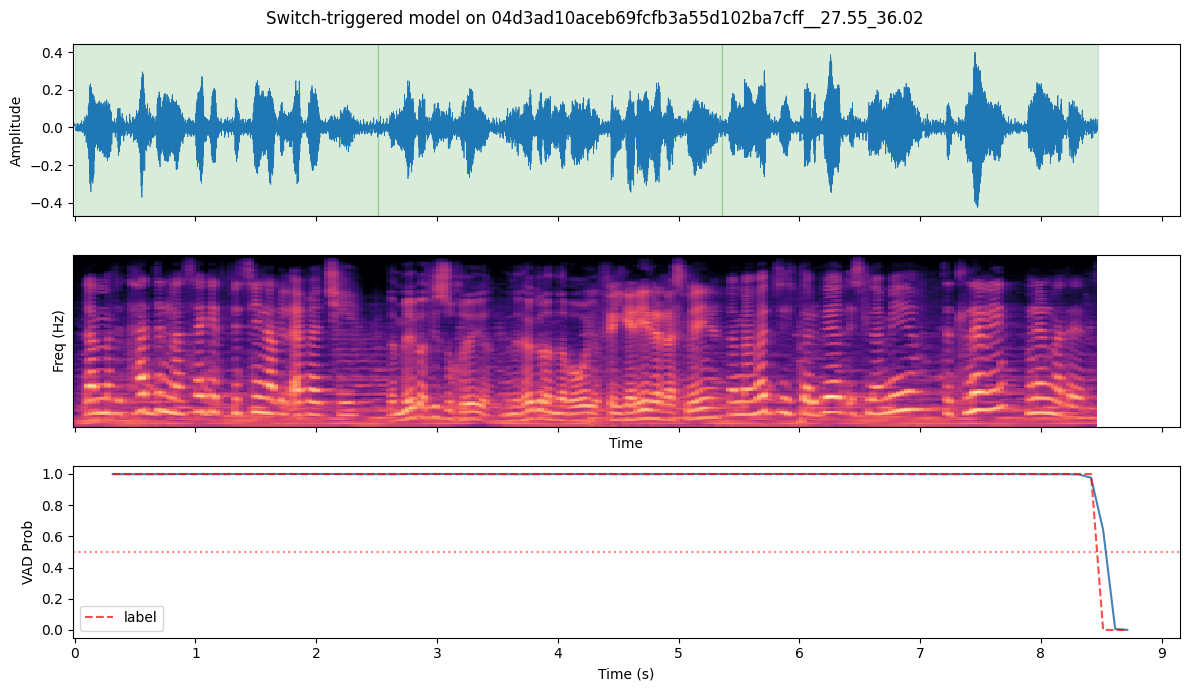

In [ ]:
import librosa, librosa.display

def plot_vad_example(m, wav_path, true_spans=None, title="", save_path=None):
    signal, sr = sf.read(wav_path)
    times, probs = sliding_window_vad(m, wav_path)
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    t_axis = np.arange(len(signal)) / sr
    axes[0].plot(t_axis, signal, linewidth=0.5); axes[0].set_ylabel("Amplitude")
    if true_spans:
        for start, end in true_spans:
            axes[0].axvspan(start, end, color="green", alpha=0.15)
    mel = librosa.feature.melspectrogram(y=signal.astype(np.float32), sr=sr)
    librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), sr=sr, x_axis="time", ax=axes[1], cmap="magma")
    axes[1].set_ylabel("Freq (Hz)")
    axes[2].plot(times, probs, color="steelblue")
    axes[2].axhline(0.5, color="red", linestyle=":", alpha=0.5)
    if true_spans:
        label_curve = np.zeros_like(times)
        for start, end in true_spans:
            label_curve[(times>=start)&(times<=end)] = 1
        axes[2].plot(times, label_curve, color="red", linestyle="--", alpha=0.7, label="label")
        axes[2].legend()
    axes[2].set_ylabel("VAD Prob"); axes[2].set_xlabel("Time (s)")
    plt.suptitle(title); plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

example_id = list(spans_by_audio.keys())[0]
plot_vad_example(models_v2["switch"], f"{DACS_AUDIO_DIR}/{example_id}.wav", spans_by_audio[example_id],
                  title=f"Switch-triggered model on {example_id}",
                  save_path=f"{PHASE4_DIR}/figures/example_{example_id}.png")

## Done

Everything from Phase 1 through the data-scaling/streaming work runs once, top to bottom, with every fix already applied. Remaining, still not code: more real (not auto-labeled) code-switch data, and the write-up itself.